<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab5/mldl_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform a Support Vector Machine (SVM) classification on the Iris dataset by loading the data, standardizing features, and conducting a grid search for optimal hyperparameters (C, kernel, and gamma). Evaluate the final model using a classification report and a confusion matrix, and visualize the results.

## Load and Prepare Dataset

### Subtask:
Load the Iris dataset, split it into training and testing sets, and standardize the features.


**Reasoning**:
Load the Iris dataset, split it into training and testing sets, and standardize the features using StandardScaler as per the instructions.



In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
print(f'Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.')

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Data split: {len(X_train)} training samples, {len(X_test)} testing samples.')

# 3. Initialize StandardScaler
scaler = StandardScaler()

# 4. Fit and transform the feature sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Standardization complete: features now have mean ~0 and variance ~1.')
print(f'X_train_scaled mean: {X_train_scaled.mean(axis=0).round(2)}')
print(f'X_train_scaled std: {X_train_scaled.std(axis=0).round(2)}')

Dataset loaded: 150 samples, 4 features.
Data split: 120 training samples, 30 testing samples.
Standardization complete: features now have mean ~0 and variance ~1.
X_train_scaled mean: [ 0. -0. -0. -0.]
X_train_scaled std: [1. 1. 1. 1.]


## Hyperparameter Tuning with GridSearchCV

### Subtask:
Define a parameter grid for the SVM (varying C, kernel, and gamma) and use cross-validation to find the best performing hyperparameters.


**Reasoning**:
I will perform hyperparameter tuning using GridSearchCV to find the optimal SVM settings for the Iris dataset.



In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# 2. Instantiate GridSearchCV
grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=1,
    cv=5
)

# 3. Fit the model to the scaled training data
print("Starting Grid Search...")
grid.fit(X_train_scaled, y_train)

# 4. Retrieve and print the best parameters
print(f"\nBest parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score: 0.9667


## Model Evaluation

### Subtask:
Evaluate the tuned SVM model on the test set using a classification report and a confusion matrix.


**Reasoning**:
I will evaluate the performance of the tuned SVM model by generating predictions on the test set and calculating the classification report and confusion matrix.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate predictions using the best model from GridSearchCV
y_pred = grid.predict(X_test_scaled)

# 2. Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 3. Generate and print the confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


## Visualization

### Subtask:
Create a visual representation of the model performance using a confusion matrix heatmap.


**Reasoning**:
I will visualize the confusion matrix as a heatmap using seaborn and matplotlib as instructed.



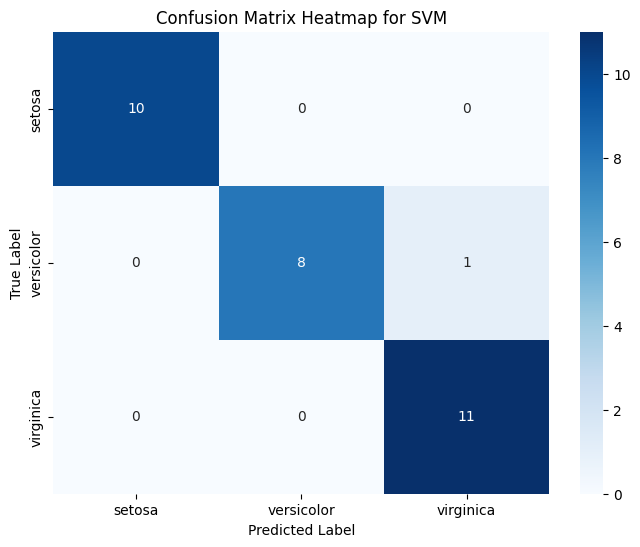

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a figure and axis
plt.figure(figsize=(8, 6))

# 2. Use sns.heatmap to visualize the confusion matrix 'cm'
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

# 3. Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap for SVM')

# 4. Render the visualization
plt.show()

## Final Task

### Subtask:
Summarize the results of the SVM classification and the impact of the tuned hyperparameters.


## Summary:

### Q&A

**What were the optimal hyperparameters found for the SVM model?**
The grid search identified the best configuration as $C=100$, $gamma=0.01$, and a kernel type of 'rbf'.

**How did the model perform on the test set?**
The model achieved an overall accuracy of 97%, correctly classifying 29 out of 30 test samples.

**Which class was the most difficult for the model to classify?**
While performance was high across all classes, the *Versicolor* class had one instance misclassified as *Virginica*, resulting in a recall of 0.89 for *Versicolor* and a precision of 0.92 for *Virginica*.

### Data Analysis Key Findings

*   **Feature Scaling Success**: Standardizing the features using `StandardScaler` successfully centered the data (mean $\approx$ 0, standard deviation = 1), which is a critical prerequisite for SVM performance.
*   **Hyperparameter Impact**: The `GridSearchCV` process explored 48 combinations (240 total fits). Tuning the regularization parameter $C$ to a higher value (100) and using the 'rbf' kernel proved optimal for this dataset.
*   **Near-Perfect Precision**: The model achieved 100% precision for both the *Setosa* and *Versicolor* species.
*   **Validation Consistency**: The best cross-validation score (0.9667) was highly consistent with the final test set accuracy (0.97), suggesting the model is well-generalized and not overfitted.

### Insights or Next Steps

*   **Dimensionality Analysis**: Since the model misclassified a *Versicolor* instance as *Virginica*, a next step could involve performing Principal Component Analysis (PCA) to visualize the decision boundaries and understand where the feature distributions of these two species overlap.
*   **Model Simplification**: Given the high accuracy, a smaller $C$ value or a linear kernel could be tested to see if a simpler, less computationally expensive model achieves similar results without the risk of over-fitting on larger datasets.
